In [54]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.messages import HumanMessage
from langgraph.graph.message import RemoveMessage

In [55]:
model = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [56]:
class ChatState(MessagesState):

    summary: str

In [57]:
def chat_node(state: ChatState):
    messages = []

    summary = state.get('summary', '')

    if summary:
        messages.append({
            'role': 'system',
            'content': f"Summary of the conversation so far: \n{summary}"
        })

    messages.extend(state['messages'])

    print(messages)

    response = model.invoke(messages)

    return {'messages': [response]}


In [70]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [59]:
def should_summarize(state: ChatState):
    return len(state['messages']) > 4  # Summarize after every 5 messages

In [60]:
builder = StateGraph(ChatState)

builder.add_node('chat', chat_node)
builder.add_node('summarize', summarize_conversation)

builder.add_edge(START, 'chat')

builder.add_conditional_edges('chat', should_summarize, {
    True: 'summarize',
    False: '__end__'
})

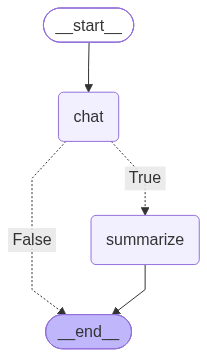

In [61]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [62]:
config = {'configurable':{'thread_id': 'thread_1'}}

In [ ]:
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print('\n------ Current State --------')
    print('summary: ', vals.get('messages', []))
    print('num_messages', len(vals.get('messages', [])))
    print('messages:')
    for m in vals.get('messages', []):
        print('-', type(m).__name__, ':', m.content[:50])

In [64]:
out = graph.invoke({'messages': [HumanMessage(content="what is quantum physics and manifestation?")]}, config = config)

print(out)

show_state()

[HumanMessage(content='what is quantum physics and manifestation?', additional_kwargs={}, response_metadata={}, id='8c5f9a1b-a6b5-4127-9787-c9afd7562dad')]
{'messages': [HumanMessage(content='what is quantum physics and manifestation?', additional_kwargs={}, response_metadata={}, id='8c5f9a1b-a6b5-4127-9787-c9afd7562dad'), AIMessage(content='## Quantum Physics in a nutshell  \n\n| Aspect | What it means (plain language) | Key ideas you may have heard |\n|--------|------------------------------|-----------------------------|\n| **Domain** | The physics that describes how the smallest pieces of matter and energy behave (atoms, electrons, photons, etc.). | “Things at the quantum level can be weird.” |\n| **Core principle #1 – Quantization** | Energy, angular momentum, and other quantities come in discrete “packets” (quanta) rather than a smooth continuum. | “Energy comes in steps, not a continuum.” |\n| **Core principle #2 – Wave‑Particle Duality** | Particles such as electrons also act l

In [65]:
from IPython.display import Markdown, display
display(Markdown(out["messages"][-1].content))

## Quantum Physics in a nutshell  

| Aspect | What it means (plain language) | Key ideas you may have heard |
|--------|------------------------------|-----------------------------|
| **Domain** | The physics that describes how the smallest pieces of matter and energy behave (atoms, electrons, photons, etc.). | “Things at the quantum level can be weird.” |
| **Core principle #1 – Quantization** | Energy, angular momentum, and other quantities come in discrete “packets” (quanta) rather than a smooth continuum. | “Energy comes in steps, not a continuum.” |
| **Core principle #2 – Wave‑Particle Duality** | Particles such as electrons also act like waves, and waves can behave like particles. | “An electron can be both a particle and a wave.” |
| **Core principle #3 – Superposition** | A system can exist in multiple possible states at once until we measure it, after which it “collapses” to one outcome. | “A particle can be in many places at once until you look.” |
| **Core principle #4 – Entanglement** | Two (or more) particles can become linked so that the state of one instantly determines the state of the other(s), no matter how far apart they are. | “Measuring one instantly fixes the other’s property.” |
| **Core principle #5 – Uncertainty** | There are limits to how precisely we can know certain pairs of properties (e.g., position and momentum) at the same time. | “The more you know about one thing, the less you know about its partner.” |
| **Mathematical tool** | The **Schrödinger equation** predicts how quantum states evolve in time; the **wavefunction** (often denoted ψ) encodes the probabilities of measurement outcomes. | “ψ encodes a cloud of possible results.” |

### Everyday analogies (with caveats)

| Analogy | What it captures | What it *misses* |
|--------|------------------|------------------|
| **Coin spinning in the air** – before it lands, it’s “both heads and tails” at once. | The idea of superposition. | The *real* quantum math isn’t just a literal coin; it’s a probability amplitude. |
| **Two perfectly synchronized dice** that always show opposite faces when rolled far apart. | Entanglement. | Real entanglement involves non‑local correlations that can’t be explained by hidden scripts. |
| **A fuzzy picture** you can only see the whole image when you zoom out; up close you only see a cloud of possibilities. | Wave‑particle duality & probability. | Quantum objects aren’t simply “blurred”; the mathematics is far richer. |

---

## Manifestation – a quick overview  

| Aspect | Typical usage | Scientific standing |
|--------|----------------|----------------------|
| **Definition (popularized)** | The belief that focused intention, visualization, and positive thinking can cause external events or circumstances to appear in one’s life. | Not a scientific theory; it belongs to self‑help and spiritual discourse. |
| **Core steps often cited** | 1. **Clarify a desire** (get specific). <br>2. **Visualize** it as already happening. <br>3. **Feel** the emotions of having it now. <br>4. **Act** in alignment (often interpreted as staying open to opportunities). | Mirrors some psychological techniques (goal‑setting, imagery) but lacks a causal mechanism that can be measured. |
| **Common claims** | “If you think about abundance enough, money will flow to you.” <br>“If you visualize healing, your body will heal.” | Many studies show that a positive mindset can improve motivation, stress levels, and even physiological outcomes—but they do **not** prove that thoughts alone create new physical entities. |

### How it’s framed by proponents

1. **Law‑of‑Attraction‑style** – the universe is thought to “respond” to the frequency of your thoughts, aligning external reality accordingly.  
2. **Quantum‑misinterpretation** – because quantum physics mentions “probability” and “observation,” some claim that *consciousness* can “collapse reality” to bring desired events into being.  
3. **Placebo‑like effect** – mental focus can alter behavior (e.g., more persistence, better risk assessment) which can indirectly create opportunities.

---

## The connection people talk about (and why it’s problematic)

| Claim | What quantum physics actually says | Why the claim is a stretch |
|-------|-----------------------------------|----------------------------|
| “Quantum physics proves that thoughts create reality.” | Quantum systems are described by wavefunctions that evolve according to the Schrödinger equation; measurement causes a *probability collapse*, **not** a decision by consciousness. | Collapse is triggered by *any* interaction that extracts information (a photon, a detector, etc.), not by an observer’s intention. Moreover, the mathematics deals with microscopic systems, not macroscopic outcomes like money or health. |
| “Everything is energy, so if you change the vibrational frequency of your thoughts you can attract different outcomes.” | Energy exists in many forms (kinetic, electromagnetic, etc.). “Vibration” is a term used in classical physics and metaphorically in mystical writing, but there is no known *global frequency* that a thought can tune. | No empirical model links human mental states to a measurable vibrational mode of matter that would cause external events to manifest. |
| “Because particles are entangled, we are all connected and can influence each other remotely.” | Entanglement is a well‑documented correlation that can be tested experimentally, but it does **not** allow faster‑than‑light signaling or control over distant events. | The no‑signalling theorem guarantees that entangled particles cannot be used to send messages or cause macroscopic changes at a distance. |

In short: **Quantum physics offers fascinating, counter‑intuitive concepts**, but those concepts are strictly *descriptive* of how microscopic systems behave. They do **not** provide a scientifically validated bridge to “manifestation” as it’s commonly advertised.

---

## A balanced perspective

1. **Use quantum ideas to broaden your imagination.**  
   - Superposition reminds us that many possibilities exist before we act.  
   - Entanglement illustrates how everything is interconnected at some level.  
   These can inspire creative thinking, which is valuable in problem‑solving.

2. **Apply evidence‑based techniques for real change.**  
   - **Goal‑setting + visualization + planning** – research shows they improve performance.  
   - **Mindfulness + emotional regulation** – reduce stress and can improve health outcomes.  
   These strategies work *without* invoking quantum mysticism.

3. **Stay critical of sweeping claims.**  
   - When a claim sounds like “Quantum physics proves that you can *just think* your way to wealth,” look for peer‑reviewed research, replication, and a clear mechanistic pathway.  
   - Remember the burden of proof: extraordinary claims require extraordinary evidence, and thus far there is none that ties conscious intention to macroscopic manifestation via quantum processes.

---

## Quick cheat‑sheet for the curious mind

| Question | Short answer |
|----------|--------------|
| **What is quantum physics?** | The branch of physics that explains how particles behave at atomic and sub‑atomic scales, emphasizing discreteness, wave‑particle duality, superposition, entanglement, and uncertainty. |
| **What is manifestation?** | (Popular usage) A mindset practice wherein focused thought/visualization is believed to bring desired external results; it draws on psychology but has no empirical mechanism for directly causing physical change. |
| **Do they really “link”?** | No scientifically validated link exists. The “quantum‑manifestation” claim misinterprets quantum terminology and overstates what physics can do. |
| **Can thinking affect reality?** | Yes, through concrete behavioral changes (e.g., increased motivation, better risk assessment), but this works via ordinary neuro‑psychological pathways, not through quantum forces. |
| **How should I use the term “quantum” responsibly?** | Reserve it for contexts where it accurately describes physics, or use it metaphorically only when clearly labeled as “metaphorical” and not as a literal scientific claim. |

---

### Final thought

Quantum physics is a **remarkably successful** theory that tells us how the universe works at its most fundamental level. Manifestation is a **human‑oriented narrative** about how thoughts might shape our lived experience. The two can intersect *only* as sources of inspiration—quantum concepts can spark imaginative ideas, and visualization techniques can motivate action—*but* they are not the same thing, and conflating them can lead to misunderstandings about what science actually proves.

If you’re interested in exploring further:

1. **Reading** – *“Quantum: A Guide for the Perplexed”* by Jim Al-Khalili (accessible popular science).  
2. **Courses** – “Quantum Mechanics for Everyone” (MIT OpenCourseWare videos are free).  
3. **Practices** – Try evidence‑based goal‑setting frameworks (SMART goals, implementation intentions) alongside mindfulness to see tangible improvements in achieving your objectives.  

Enjoy the journey of learning—both the quantum world and the inner world of intention make for endlessly fascinating realms!

In [66]:
out = graph.invoke({'messages': [HumanMessage(content="I s there any relationship between quantum physics and manifestation?")]}, config = config)

print(out)

show_state()

[HumanMessage(content='what is quantum physics and manifestation?', additional_kwargs={}, response_metadata={}, id='8c5f9a1b-a6b5-4127-9787-c9afd7562dad'), AIMessage(content='## Quantum Physics in a nutshell  \n\n| Aspect | What it means (plain language) | Key ideas you may have heard |\n|--------|------------------------------|-----------------------------|\n| **Domain** | The physics that describes how the smallest pieces of matter and energy behave (atoms, electrons, photons, etc.). | “Things at the quantum level can be weird.” |\n| **Core principle #1 – Quantization** | Energy, angular momentum, and other quantities come in discrete “packets” (quanta) rather than a smooth continuum. | “Energy comes in steps, not a continuum.” |\n| **Core principle #2 – Wave‑Particle Duality** | Particles such as electrons also act like waves, and waves can behave like particles. | “An electron can be both a particle and a wave.” |\n| **Core principle #3 – Superposition** | A system can exist in mul

In [67]:
from IPython.display import Markdown, display
display(Markdown(out["messages"][-1].content))

**Short answer:**  
The mainstream, experimentally verified theory of quantum physics does **not** provide a scientific mechanism for “manifestation” in the popular self‑help sense (i.e., the idea that thoughts alone can directly create external events or outcomes). The two domains intersect only at the level of **metaphorical inspiration**, not at the level of causal law.

Below is a step‑by‑step breakdown of why the connection is usually exaggerated, what quantum physics *actually* says, and what **does** have empirical support when it comes to influencing reality through mindset and intention.

---

## 1. What quantum physics **actually** tells us

| Principle | What it *means* in physics | Common pop‑culture misinterpretation |
|-----------|---------------------------|------------------------------------|
| **Quantization** | Physical quantities (energy, angular momentum, etc.) come in discrete packets called *quanta*. | “Everything is made of energy packets that can be rearranged by intention.” |
| **Wave‑Particle Duality** | Particles exhibit both particle‑like and wave‑like behavior; the wavefunction ψ encodes a *probability amplitude*. | “A thought is a ‘wave’ that can shape material reality.” |
| **Superposition** | Before measurement a system can exist in a linear combination of multiple states; measurement *collapses* the state to one outcome. | “If you focus on a possibility, the universe “chooses” it.” |
| **Entanglement** | Two or more particles share a joint state such that the measurement of one instantly determines the other, regardless of distance. | “We are all ‘quantum‑connected’; our thoughts instantly affect distant events.” |
| **Uncertainty Principle** | Certain pairs of properties (e.g., position/momentum) cannot both be known precisely at the same time. | “The universe is fundamentally unpredictable, so anything can happen if you believe hard enough.” |
| **Measurement / Decoherence** | Interaction with an environment (a photon, a detector, etc.) leads to *decoherence*, effectively selecting a single outcome from the superposition. This process does **not** require a conscious observer. | “Consciousness collapses reality, so you can ‘choose’ outcomes just by thinking about them.” |

### Key Experimental Facts

1. **Decoherence** is a physical, non‑conscious process. Any macroscopic interaction (a photon hitting a detector, a collision, etc.) causes superpositions to lose coherence extremely quickly (often 10⁻¹⁵ – 10⁻¹² seconds).  
2. **No‑signalling theorem** proves that entanglement cannot be used for faster‑than‑light communication or for exerting controllable influence at a distance.  
3. **Quantum theory operates at the microscopic scale**. Macroscopic objects (people, tables, money, health) are described statistically by the same theory, but the collective behavior overwhelmingly averages out quantum fluctuations; they are effectively classical.

**Bottom line:** Quantum physics provides a *mathematical description* of how microscopic systems behave probabilistically, but it does **not** contain a rule that says “a focused intention causes a specific macroscopic change.” The “collapsing” of a wavefunction is triggered by *any* interaction that yields information, not by a person’s desire or belief.

---

## 2. What “manifestation” really means in popular usage

| Step often cited | Psychological counterpart | Scientific evidence |
|------------------|---------------------------|---------------------|
| **Clarify a desire** (be specific) | Goal‑setting theory | Strongly supported – specific, challenging goals improve performance. |
| **Visualize the outcome** | Mental imagery, motor simulation | Improves skill learning and confidence, but only when paired with actual practice. |
| **Feel the emotion of having it now** | Emotional regulation, self‑affirmation | Linked to reduced stress and increased motivation; does not directly alter external physics. |
| **Act in alignment / stay open to opportunities** | Behavioral activation, chance‑encounter preparation | Evidence that people who maintain a positive expectancy notice more relevant opportunities (the “availability heuristic”). |

These practices are **evidence‑based** for improving motivation, resilience, and behavior, but they **do not** entail a literal “thought‑creates‑matter” mechanism. Instead, they work through *behavioral* and *neuro‑psychological* pathways: a positive mindset can make you more persistent, better at spotting opportunities, and less stressed, all of which can indirectly influence outcomes.

---

## 3. Where the two discourses sometimes *appear* to overlap

| Pop‑culture claim | Why it feels plausible | Why it’s scientifically inaccurate |
|-------------------|------------------------|-------------------------------------|
| “Quantum physics says everything is made of energy, and energy can be reshaped by thought.” | Quantum objects are indeed quantized packets of energy; everything *is* made of fields and particles. | Energy cannot be “reshaped by thought” in any known way. The only known ways to change energy distributions involve physical interactions (forces, fields, particle collisions), not mental intention. |
| “Entanglement shows we are all connected, so we can influence each other instantly.” | Entangled particles exhibit instant correlations. | Correlations are *passive*—they cannot be controlled to send messages or force a specific outcome. Moreover, they do not scale up to macroscopic systems in any controllable fashion. |
| “Measurement collapses reality; if you’re the observer you can choose the result.” | In experiments a measurement “selects” one outcome. | Measurement is any interaction that extracts information; it does **not** require a conscious observer. Also, the outcome is fundamentally probabilistic, not controllable at will. |

Thus, whenever a claim says *“quantum physics proves manifestation works,”* it is **over‑extending** the physics beyond what experiments can tell us.

---

## 4. A realistic way to use quantum‑inspired ideas

1. **Cultivate curiosity about uncertainty.**  
   - Superposition reminds us that *many* possibilities exist before we act. Use that mindset to generate creative options rather than fixating on a single predetermined outcome.

2. **See connections.**  
   - Entanglement can be a metaphor for interdependence (e.g., how one person’s actions affect a community). It encourages social responsibility, not magical causation.

3. **Embrace probabilism.**  
   - Quantum theory is fundamentally about probabilities. Adopt a probabilistic view of goals: “I have a 30 % chance of landing this interview if I prepare well.” This realistic framing reduces magical thinking and promotes concrete planning.

4. **Leverage the metaphor for motivation.**  
   - Visualizing a quantum “cloud of possibilities” can be a vivid way to stay open to multiple opportunities, which can improve persistence—a well‑supported psychological effect.

**Bottom line:** Quantum metaphors can be *useful* tools for personal development, but they should be kept clearly in the realm of *analogy*, not literal physical law.

---

## 5. TL;DR (Take‑away points)

| Question | Answer |
|----------|--------|
| **Is there a direct scientific link between quantum physics and manifestation?** | **No.** Quantum mechanics describes microscopic systems; it does not provide a causal mechanism whereby focused thought directly creates external events. |
| **Can quantum ideas inspire better mindset practices?** | Yes—superposition and interconnectedness are great metaphors for exploring options and recognizing social ties, *provided* they are used as analogies, not as literal physical laws. |
| **What does science say about “thinking makes reality”?** | A focused mindset can influence *behavior* (effort, persistence, openness to opportunity), which can *indirectly* affect outcomes, but this works via ordinary neuro‑psychological pathways, not through quantum processes. |
| **Should I use “quantum manifestation” as a self‑help technique?** | You can enjoy the metaphor, but be skeptical of any claim that it guarantees results by “aligning your vibration” or “collapsing reality.” Rely on evidence‑based strategies (goal setting, deliberate practice, stress management) instead. |

---

### Final Thought

Quantum physics is a spectacularly successful theory that tells us **how** the universe operates at its most fundamental level. Manifestation, as it’s commonly presented, is a **human‑psychology narrative** about how our thoughts might shape our lives. The two can meet only at the level of *metaphor*—a way to make abstract scientific ideas relatable—while *strict scientific* causality remains firmly in the domain of physical processes that can be measured, tested, and replicated, independent of any mental intention.

If you’re intrigued, dive into the **physics** to appreciate the genuine weirdness of the quantum world, and simultaneously explore **psychology** (goal‑setting, visualization, mindfulness) to see how your own mind can more reliably influence the world **through action**, not through magical “thought‑to‑matter” conversion. Both journeys are rewarding, but they occupy distinct intellectual territories.

In [ ]:
out = graph.invoke({'messages': [HumanMessage(content="How can i use quantum physics to manifest new job opportunities?")]}, config = config)

print(out)

show_state()

[{'role': 'system', 'content': 'Summary of the conversation so far: \nSure thing! It looks like the conversation you’d like summarized wasn’t included in your message. Could you please paste the chat or thread you want me to condense? Once I have the text, I’ll provide a concise summary for you.'}, HumanMessage(content='How can i use quantum physics to manifest new job opportunities?', additional_kwargs={}, response_metadata={}, id='87a7d83b-ff21-4cda-baba-1cfc0e37f875'), AIMessage(content='**Short answer:**  \nQuantum physics can’t *directly* create a new job for you, but it can give you a set of **mental models** that help you stay open to possibilities, act with purpose, and build the kinds of connections that make career moves happen. Use the language of quantum concepts as **metaphors**—not as literal mechanisms—to design a practical, evidence‑based job‑search strategy.\n\nBelow is a step‑by‑step guide that blends:\n\n1. **What quantum ideas actually mean** (in plain language).  \

In [69]:
from IPython.display import Markdown, display
display(Markdown(out["messages"][-1].content))

**Short answer:**  
Quantum physics can’t *directly* create a new job for you, but it can give you a set of **mental models** that help you stay open to possibilities, act with purpose, and build the kinds of connections that make career moves happen. Use the language of quantum concepts as **metaphors**—not as literal mechanisms—to design a practical, evidence‑based job‑search strategy.

Below is a step‑by‑step guide that blends:

1. **What quantum ideas actually mean** (in plain language).  
2. **How those ideas can be turned into useful mental habits** for career development.  
3. **Concrete actions** that research shows increase your chances of landing new opportunities.  

---

## 1. The Quantum Concepts (in a nutshell)

| Concept | Real physics meaning | Metaphor for career work | Why it helps (psychology) |
|---------|----------------------|--------------------------|---------------------------|
| **Superposition** | A quantum system can exist in several possible states simultaneously *until measured*. | Keep *multiple* career possibilities open before you “collapse” on a decision. | Prevents premature fixation, encourages brainstorming and flexibility. |
| **Wave‑Particle Duality** | Particles behave like waves (delocalized) *and* like localized objects depending on how you look at them. | Your **personal brand** can be both a *presence* in many places (online, networking) and a *specific* role you’re targeting. | Helps you think about reputation as a diffuse field that can be focused when needed. |
| **Entanglement** | Two particles share a state so that measuring one instantly defines the other, no matter the distance. | Your **professional relationships** can create “instant” updates about opportunities that exist far away (a colleague in another company). | Shows the power of a strong network to bring you relevant leads quickly. |
| **Uncertainty Principle** | There is a fundamental limit to how precisely you can know both a particle’s position and momentum. | You can’t know *exactly* when or how a job will appear, but you can control the *probability* of spotting it. | Encourages proactive behavior rather than passive waiting. |
| **Decoherence / Measurement** | Interaction with an environment forces a superposition to “collapse” into a definite outcome. | Your **actions** (applying, interviewing, following up) are the “measurements” that turn a possibility into a concrete result. | Highlights the causal link between what you do and what you get. |

> **Bottom line:** Think of these quantum ideas as *ways of framing* your career planning, not as scientific levers that magically rewrite reality.

---

## 2. Turn the metaphors into a concrete workflow

### Step 1 – Clarify the “state” you want (the “goal wavefunction”)

1. **Write a concise description of the role you’re aiming for** (title, industry, key skill set, work style).  
   *Example*: “Product Manager, SaaS, data‑driven decision‑making, remote‑first.”  
2. **List the *probabilities* of different avenues** that could get you there (e.g., internal transfer, external hire, freelance project → full‑time).  
   *Outcome*: A mental map that keeps *multiple* superposed possibilities alive.

### Step 2 – Build a “probability field” (network entanglement)

| Action | How it mirrors entanglement | Practical tip |
|--------|-----------------------------|---------------|
| **Identify 5–7 people** who already work in or adjacent to your target role | They become “entangled” nodes that instantly surface openings, advice, or referrals. | Use LinkedIn, alumni groups, meetup groups, or industry Slack channels. Reach out with a *specific* question (e.g., “What’s the biggest challenge your team faces right now?”). |
| **Share a concise “value statement”** about what you bring | In quantum terms, you’re *broadcasting* your state, making it easier for others to collapse a relevant outcome. | 30‑second elevator pitch: “I help product teams turn complex data into user‑friendly features, recently increasing retention by 12%.” |
| **Follow up** after a conversation with a brief, value‑adding note | Reinforces the entangled link and nudges it toward a concrete opportunity. | Send a short thank‑you + a relevant article or a quick update on a project you mentioned. |

### Step 3 – Create “measurement moments” (actionable collapse)

These are the *small, concrete* steps that force the superposition to resolve into a job outcome.

| Measurement type | Example action | Why it works |
|------------------|----------------|--------------|
| **Application** | Submit a tailored resume + cover letter to one new posting each day. | Each submission is a measurement that tests the market’s response. |
| **Informational interview** | Schedule 15‑minute coffee chats with 2–3 contacts per week. | Each chat collapses a possibility into concrete insights and often ends with an invitation to apply later. |
| **Skill‑showcase** | Publish a short case study or blog post that solves a problem relevant to your target industry. | This acts like a “probe” that forces the system to reveal interest (comments, inbound inquiries). |
| **Portfolio/ project sprint** | Build a micro‑project that demonstrates the exact skill the job requires (e.g., a KPI dashboard using a specific tech stack). | Demonstrates competence and lets recruiters *measure* you directly. |

> **Key insight:** The more “measurements” you deliberately create, the higher the overall probability of collapsing into an actual opportunity.

### Step 4 – Embrace the Uncertainty Principle

1. **Accept that timing is probabilistic.** Even with perfect preparation, the *exact* moment a role appears is outside your control.  
2. **Maintain a “probability buffer.”** Keep 2–3 parallel avenues alive (e.g., one internal move, one external search, one freelance contract).  
3. **Use periodic reviews** (every 2 weeks) to assess which avenues are gaining traction and adjust focus.

### Step 5 – “Decohere” unproductive habits

Quantum decoherence is what destroys a delicate superposition. In career terms:

| Unproductive habit | How it acts like decoherence | Fix |
|--------------------|------------------------------|-----|
| **All‑or‑nothing thinking** (“I’ll only apply if I meet 100% of the requirements”) | Collapses the hopeful wavefunction into a dead end. | Adopt a *“minimum viable fit”* rule – apply when you meet *most* critical criteria. |
| **Stagnant networking** (same 2–3 contacts, no new introductions) | Leaves your entanglement field static, reducing signal flow. | Schedule a “new‑person outreach” target each month. |
| **Over‑visualizing without action** | Turns intention into a static mental image, not a measured outcome. | Pair each visualization session with a specific action item (e.g., “After visualizing landing a PM role, I will update my LinkedIn headline.”). |

---

## 3. A sample 4‑week “Quantum‑Inspired Job‑Search Sprint”

| Week | Quantum‑themed focus | Concrete tasks |
|------|----------------------|----------------|
| **1 – Superposition Planning** | Open all possible pathways. | • Draft 3 distinct role descriptions you’d consider.<br>• List 5 industries where those roles exist.<br>• Identify 2 “skill gaps” you’d be willing to fill. |
| **2 – Entanglement Building** | Expand network to create “quantum links.” | • Send connection requests to 10 people in those industries (personalize each).<br>• Publish one short post sharing a recent win or insight relevant to your target field.<br>• Request 1‑hour informational interviews with 3 contacts. |
| **3 – Measurement & Collapse** | Trigger concrete outcomes. | • Apply to 5 curated job postings (tailor each résumé).<br>• Follow up on every interview invitation with a thank‑you + additional value (article, data point).<br>• Complete one mini‑project that showcases a target skill; share it on relevant platforms. |
| **4 – Review & Adjust (Uncertainty Management)** | Measure results, collapse the wavefunction into the next step. | • Count applications, responses, interview invites, and project interest.<br>• Identify which superposition pathways yielded the highest probability of success.<br>• Set a new set of goals for the next month, keeping at least two parallel tracks alive. |

---

## 4. Evidence‑Based Practices That Complement the Quantum Metaphor

| Practice | What the research says | How to frame it with quantum language |
|----------|------------------------|---------------------------------------|
| **SMART goal setting** | Specific, Measurable, Achievable, Relevant, Time‑bound goals increase success rates (Locke & Latham, 2002). | Treat each goal as a “measurement” that collapses a part of your probability field. |
| **Implementation intentions** (“If‑then” plans) | Increases follow‑through by 30–40% (Gollwitzer, 1999). | “If I receive an interview invitation, then I will send a follow‑up note within 24 hours.” |
| **Deliberate practice** | Focused, goal‑oriented rehearsal improves skill mastery (Ericsson et al., 1993). | Build “quantum skill quanta” – tiny packets of competence that add up to a larger state. |
| **Positive affect & motivation** | Good mood expands the scope of attention and creative problem solving (Fredrickson, 2001). | Visualize a *superposition* of possibilities; let curiosity keep many doors open. |
| **Networking reciprocity** | People are more likely to help those who help them (Granovetter, 1973). | Entangle by offering value first—share an article, make an introduction, give feedback. |

---

## 5. Pitfalls to Avoid (When “Quantum” Gets Mis‑Used)

| Misconception | Why it’s scientifically inaccurate | Real‑world impact |
|---------------|-----------------------------------|-------------------|
| “If I think about the job hard enough, the universe will bring it to me.” | No known physical law links thought alone to macroscopic outcomes. | Leads to passive waiting and disappointment. |
| “Entanglement means my friend can instantly ‘send’ me a job.” | Entanglement cannot transmit controllable signals. | Overestimates the speed of network referrals; undervalues proactive outreach. |
| “The more I ‘visualize’ a result, the more likely it will happen.” | Visualization improves motivation only when paired with action. | May cause complacency; you still need to *measure* the outcome. |
| “Quantum healing / quantum energy can cure burnout.” | Quantum effects are negligible at biological scales; no proven mechanism. | Distraction from evidence‑based health practices. |

> **Bottom line:** Use the quantum vocabulary **as a metaphorical toolbox**, not as a literal explanation of how the world works. The real leverage comes from **behavior, preparation, and connection**, which are fully explainable without invoking quantum mechanics.

---

## 6. Quick “Quantum Manifestation Cheat Sheet” for Job Seekers

| Quantum Idea | Practical Daily Habit | Result You’re Aiming For |
|--------------|------------------------|--------------------------|
| **Superposition** | Keep a running list of *at least three* different job titles/industries you’re open to. | Flexibility → more opportunities appear. |
| **Entanglement** | Reach out to one new contact *every* workday (LinkedIn, email, events). | Expanded network → higher chance of referral. |
| **Wave‑Particle Duality** | Publish a short insight or project update *once* a week that showcases your expertise. | Visibility → people start seeing you as the “particle” they need. |
| **Uncertainty** | Schedule a “probability check‑in” every Friday (review what’s moving, adjust next week’s actions). | Adaptive strategy → you’re always moving toward the highest‑probability path. |
| **Measurement/Collapse** | Submit *one* tailored application or send *one* follow‑up each day. | Concrete actions → real interviews and offers. |

---

### Final Thought

Quantum physics offers **rich metaphors**—superposition, entanglement, uncertainty—that can be powerfully reframed to:

* Keep you curious and open to many possibilities.  
* Structure your networking and application process as intentional “measurements.”  
* Turn abstract optimism into concrete daily behaviors that statistically increase your odds of landing a new role.

When you pair these metaphorical frames with **evidence‑based tactics** (goal setting, deliberate practice, network reciprocity, and consistent action), you create a *robust* career‑mobility strategy—one that works **whether or not** quantum mechanics ever turns out to be the hidden engine behind everyday life.

Good luck, and may your probability cloud collapse into a great new opportunity soon! 🚀